[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/fast_track/06_pandas_fundamentals.ipynb)

# 📓 Notebook 6 (fast track) — Pandas Fundamentals: Your First Real DataFrame

> **Module:** Data Science Libraries · **Estimated time:** 30–40 min · **Difficulty:** Beginner

You can do real data work in pure Python — that's exactly what you did with lists and dicts (Notebook 3). But once your data is more than a handful of rows, you want a **proper table**: row + column labels, fast filtering, group-by operations, reading and writing CSV files. That is **pandas**.

Pandas is *the* library every data scientist touches every day. This notebook gives you a working preview: enough to be productive day to day — the canonical course adds the deeper dive (NumPy and more pandas) when you want it.

We'll work the whole notebook as **one investigation** of a single dataset: a **log of LLM API calls** — model, token usage, cost, latency, customer segment — the kind of table your support bot would generate in a day. The question driving us throughout: *where is the money and the slowness going, and which model or segment is responsible?* Every pandas verb you learn earns its place by answering one more piece of that question, and by the end you'll have built the DataFrame, filtered it, grouped it, and plotted the answer.

> 🧭 **Mental model for this notebook.** A DataFrame is a **spreadsheet you talk to in code instead of with a mouse.** And almost every task, no matter how fancy it looks, is one of just three moves: **pick rows** (filtering), **pick columns** (selection), or **compute** (a formula or an aggregate). Group-by is just "compute, once per category." Keep those three moves in mind and pandas stops being a wall of methods.

## 🎯 Learning objectives

1. Build a `DataFrame` from a dict and from a CSV.
2. Inspect a new dataset with the standard "first five commands".
3. Select columns and rows (`.loc` vs `.iloc`).
4. Filter rows with **boolean masks** — the pandas idiom.
5. Add derived columns from formulas.
6. Use `groupby` to compute aggregates by category.
7. Draw a first plot directly from a DataFrame.

## ✅ Prerequisites

Notebooks 1–4.

> 🏎️ **You're on the fast track.** This is a trimmed version of the canonical [`02_data_science/07_pandas_fundamentals.ipynb`](../02_data_science/07_pandas_fundamentals.ipynb) — pandas fundamentals. The deepest Stretch exercises (A and B) and the 🎁 Bonus mini-project have been removed to keep the notebook to ~30–40 minutes; the harder Stretch C and D are kept. Open the canonical version once you want the deeper material.

---


## 1. The pandas mental model

Pandas has two core objects:

| Object        | Conceptually          | Compare to                        |
|---------------|-----------------------|-----------------------------------|
| `Series`      | A single column       | a labelled NumPy 1-D array        |
| `DataFrame`   | A whole table         | a labelled 2-D array / SQL table  |

```
   ┌────────────────  DataFrame  ────────────────┐
   │  request_id   model       tokens   cost    │
   │  req_001      gpt-4o-mini  482     0.00029 │
   │  req_002      claude-haiku 612     0.00037 │
   │  ...                                       │
   └────────────────────────────────────────────┘
                ↑                  ↑
               row              column
            (a record)        (a Series)
```

If you understand a list-of-dicts from Notebook 3, you already understand a DataFrame — pandas just gives you a *much* better toolkit for working with it.

In [1]:
# The standard import aliases — you'll see "pd" and "np" in every pandas notebook ever
import pandas as pd
import numpy as np

print(f"pandas version: {pd.__version__}")
print(f"numpy  version: {np.__version__}")


pandas version: 3.0.3
numpy  version: 2.4.6


## 2. Creating a DataFrame from a dict

The most natural way to build a small DataFrame is from a dict where **keys are column names** and **values are lists** (one per row).

In [2]:
# A small log of LLM API calls from yesterday's batch
data = {
    "request_id":     ["req_001", "req_002", "req_003", "req_004", "req_005", "req_006", "req_007", "req_008"],
    "model":          ["gpt-4o-mini", "gpt-4o-mini", "claude-haiku", "gpt-4o-mini",
                       "claude-haiku", "gpt-4o-mini", "claude-haiku", "gpt-4o-mini"],
    "tokens_in":      [482, 612, 510, 1180, 720,  430,  890, 240],
    "tokens_out":     [121, 158, 144,  205, 192,  118,  201,  87],
    "latency_ms":     [1820, 2150, 1640, 3180, 2410, 1740, 2530, 1380],
    "customer_seg":   ["SMB", "Enterprise", "SMB", "Enterprise",
                       "Mid-market", "SMB", "Enterprise", "SMB"],
}

df = pd.DataFrame(data)
df


,request_id,model,tokens_in,tokens_out,latency_ms,customer_seg
0,req_001,gpt-4o-mini,482,121,1820,SMB
1,req_002,gpt-4o-mini,612,158,2150,Enterprise
2,req_003,claude-haiku,510,144,1640,SMB
3,req_004,gpt-4o-mini,1180,205,3180,Enterprise
4,req_005,claude-haiku,720,192,2410,Mid-market
5,req_006,gpt-4o-mini,430,118,1740,SMB
6,req_007,claude-haiku,890,201,2530,Enterprise
7,req_008,gpt-4o-mini,240,87,1380,SMB


**A pandas tip.** Inside Jupyter, just typing the variable name (`df`) at the bottom of a cell renders a beautifully formatted HTML table. Try `print(df)` *and* just `df` — the latter is what you'll prefer.

## 3. Inspecting a DataFrame

Whenever you load a new dataset, run these commands first. They tell you the *shape*, the *types*, and the *typical values* before you do anything else. Skipping this step is one of the most common rookie mistakes.

In [3]:
print("Shape (rows, cols):", df.shape)
print("\nColumn names :", df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Shape (rows, cols): (8, 6)

Column names : ['request_id', 'model', 'tokens_in', 'tokens_out', 'latency_ms', 'customer_seg']

Data types:
request_id        str
model             str
tokens_in       int64
tokens_out      int64
latency_ms      int64
customer_seg      str
dtype: object


In [4]:
# The first / last few rows
print("--- head(3) ---")
print(df.head(3))

print("\n--- tail(2) ---")
print(df.tail(2))


--- head(3) ---
  request_id         model  tokens_in  tokens_out  latency_ms customer_seg
0    req_001   gpt-4o-mini        482         121        1820          SMB
1    req_002   gpt-4o-mini        612         158        2150   Enterprise
2    req_003  claude-haiku        510         144        1640          SMB

--- tail(2) ---
  request_id         model  tokens_in  tokens_out  latency_ms customer_seg
6    req_007  claude-haiku        890         201        2530   Enterprise
7    req_008   gpt-4o-mini        240          87        1380          SMB


In [5]:
# Quick statistical summary for numeric columns
df.describe()


,tokens_in,tokens_out,latency_ms
count,8.000000,8.000000,8.000000
mean,633.000000,153.250000,2106.250000
std,294.437963,43.489736,584.023911
min,240.000000,87.000000,1380.000000
25%,469.000000,120.250000,1715.000000
50%,561.000000,151.000000,1985.000000
75%,762.500000,194.250000,2440.000000
max,1180.000000,205.000000,3180.000000


In [6]:
# Schema and non-null counts — your missing-data canary
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   request_id    8 non-null      str  
 1   model         8 non-null      str  
 2   tokens_in     8 non-null      int64
 3   tokens_out    8 non-null      int64
 4   latency_ms    8 non-null      int64
 5   customer_seg  8 non-null      str  
dtypes: int64(3), str(3)
memory usage: 715.0 bytes


## 4. Selecting columns

These three patterns appear in every pandas notebook:

```python
df["tokens_in"]                       # one column → Series
df[["request_id", "tokens_in"]]       # several columns → DataFrame
df.tokens_in                          # attribute-style (only when the name is a valid identifier)
```

In [7]:
# One column → Series
tokens = df["tokens_in"]
print(tokens)
print(f"\ntype: {type(tokens).__name__}")


0     482
1     612
2     510
3    1180
4     720
5     430
6     890
7     240
Name: tokens_in, dtype: int64

type: Series


In [8]:
# Several columns → DataFrame
subset = df[["request_id", "model", "tokens_in", "tokens_out"]]
subset


,request_id,model,tokens_in,tokens_out
0,req_001,gpt-4o-mini,482,121
1,req_002,gpt-4o-mini,612,158
2,req_003,claude-haiku,510,144
3,req_004,gpt-4o-mini,1180,205
4,req_005,claude-haiku,720,192
5,req_006,gpt-4o-mini,430,118
6,req_007,claude-haiku,890,201
7,req_008,gpt-4o-mini,240,87


---

### ✋ Quick exercise (~2 min) — Build a slim report view

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Your manager wants a compact view of `df` with **only** the `request_id`, `tokens_in`, and `latency_ms` columns. Create that 3-column DataFrame and display its **first 3 rows** — using only column selection.

In [9]:
# ✍️ Your turn 👇
# Build a 3-column report DataFrame, then show its first 3 rows.
report = ...


<details>
<summary>✅ <b>Solution</b></summary>

```python
report = df[["request_id", "tokens_in", "latency_ms"]]
report.head(3)
```

Passing a **list** of column names returns a new DataFrame with just those columns, in that order — exactly what you'd paste into a report. `.head(3)` then shows the first three rows.
</details>

## 5. Selecting rows — `loc` vs `iloc`

Pandas gives you **two** ways to slice rows. The difference matters once your DataFrame has a non-default index.

| Indexer | What it uses          | Endpoint inclusive?   |
|---------|------------------------|-----------------------|
| `.loc`  | **labels** (the index) | yes (`df.loc[0:2]` returns 3 rows) |
| `.iloc` | **integer positions**  | no (`df.iloc[0:2]` returns 2 rows) |

In [10]:
# .loc — label-based
print("df.loc[0]:")
print(df.loc[0])           # first row → Series

print("\ndf.loc[0:2, ['request_id', 'tokens_in']]:")
print(df.loc[0:2, ["request_id", "tokens_in"]])


df.loc[0]:
request_id          req_001
model           gpt-4o-mini
tokens_in               482
tokens_out              121
latency_ms             1820
customer_seg            SMB
Name: 0, dtype: object

df.loc[0:2, ['request_id', 'tokens_in']]:
  request_id  tokens_in
0    req_001        482
1    req_002        612
2    req_003        510


In [11]:
# .iloc — position-based
print("df.iloc[0]:")
print(df.iloc[0])

print("\ndf.iloc[0:2, 0:3]:")
print(df.iloc[0:2, 0:3])    # first 2 rows, first 3 cols


df.iloc[0]:
request_id          req_001
model           gpt-4o-mini
tokens_in               482
tokens_out              121
latency_ms             1820
customer_seg            SMB
Name: 0, dtype: object

df.iloc[0:2, 0:3]:
  request_id        model  tokens_in
0    req_001  gpt-4o-mini        482
1    req_002  gpt-4o-mini        612


> 🎯 **Rule of thumb.** Prefer `.loc` — it reads almost like English. Use `.iloc` only when you really do mean "the *n*-th row" regardless of labels.

### 🔬 What actually happens — `loc` vs `iloc` when the index isn't `0,1,2`

So far `df.loc[0]` and `df.iloc[0]` returned the **same** row — but only by accident: our index *happened* to be `0,1,2,…`, so label `0` and position `0` coincided. The moment the index is something else (after filtering, after `set_index`, after sorting), they diverge. Here is the mental model:

- **`.loc` is LABEL-based** — it looks up the value *printed in the index*. `df.loc["b"]` means "the row whose index label is `b`".
- **`.iloc` is POSITION-based** — it counts from the top, `0, 1, 2, …`, ignoring whatever the labels say. `df.iloc[0]` always means "the *first* row".

Picture a tiny frame with a string index:

```text
         index  │  val          .loc["b"]  → label "b" → val 20   (2nd row here, but that's incidental)
        ────────┼──────         .iloc[0]   → position 0 → val 10   (always the FIRST row)
   pos 0 →   a  │  10           .iloc[-1]  → last position → val 30
   pos 1 →   b  │  20
   pos 2 →   c  │  30           df.loc[0]  → KeyError!  there is no LABEL 0 anymore
```

The trap: after you filter a DataFrame, pandas **keeps the original labels**, so the surviving rows have a gappy index like `1, 3, 4`. Now `df.iloc[0]` is the first surviving row, but `df.loc[0]` raises `KeyError` because label `0` was filtered away.


In [12]:
# PROOF — index is NOT 0,1,2, so .loc and .iloc point at different rows
mini = pd.DataFrame({"val": [10, 20, 30]}, index=["a", "b", "c"])
print(mini, "\n")

print("iloc[0]  (position 0, the FIRST row):", mini.iloc[0]["val"])   # 10
print("loc['b'] (label 'b'):                ", mini.loc["b"]["val"])  # 20
print("iloc[1]  (position 1) == loc['b']?   ", mini.iloc[1]["val"] == mini.loc["b"]["val"])  # True

# The classic filtering trap: surviving rows keep their ORIGINAL labels.
left = df[df["tokens_in"] > 600]      # keeps a gappy index, e.g. 1, 3, 4, 6
print("\nIndex left after filtering tokens_in > 600:", left.index.tolist())
print("iloc[0] request_id (first surviving row):", left.iloc[0]["request_id"])
try:
    left.loc[0]                       # label 0 was filtered out → KeyError
except KeyError:
    print("loc[0] -> KeyError: label 0 no longer exists (iloc[0] still works!)")


   val
a   10
b   20
c   30 

iloc[0]  (position 0, the FIRST row): 10
loc['b'] (label 'b'):                 20
iloc[1]  (position 1) == loc['b']?    True

Index left after filtering tokens_in > 600: [1, 3, 4, 6]
iloc[0] request_id (first surviving row): req_002
loc[0] -> KeyError: label 0 no longer exists (iloc[0] still works!)


### 🧠 `loc` vs `iloc` vs boolean mask — one table

| You write | Selects by | `mini.…[0]` on index `['a','b','c']` |
|---|---|---|
| `df.loc[lbl]` | **label** (index value) | `mini.loc[0]` → `KeyError` (no label `0`) |
| `df.iloc[pos]` | **integer position** | `mini.iloc[0]` → first row (`val=10`) |
| `df[df.col > x]` | a **boolean Series** | keeps rows where the mask is `True` |

**Boolean masking is the same idea, one level up.** `df["tokens_in"] > 500` doesn't return rows — it returns a `True`/`False` **Series the same length as `df`**. Indexing with that Series keeps only the `True` rows. Combine masks with **`&`** (and) / **`|`** (or), and **every condition needs parentheses** because `&`/`|` bind tighter than `>`/`==`:

```python
df[(df["tokens_in"] > 500) & (df["latency_ms"] > 2000)]   # ✅ parens required
df[ df["tokens_in"] > 500  &  df["latency_ms"] > 2000 ]   # ❌ ValueError / wrong result
```

> ⚠️ **Two traps in one.** (1) Use `&`/`|`, *never* Python's `and`/`or`, on Series — `and` tries to collapse the whole Series to one truth value and raises `ValueError`. (2) After filtering, reach for `.iloc` (position) or `.reset_index(drop=True)` if you want clean `0,1,2…` labels back — `.loc` with an old integer label will surprise you.

> 🎯 **Rule of thumb (refined).** Use `.loc` when you mean *"the row called X"* and `.iloc` when you mean *"the n-th row"*. They only look interchangeable while the index is the default `0,1,2,…` — which is exactly when bugs hide.


## 6. Filtering — the boolean-mask idiom

Now the first of our three moves in earnest: **picking rows.** Our investigation rarely cares about *all* the calls — it cares about the expensive ones, the slow ones, the ones from a particular segment. Filtering is how you zoom in. The pattern is **the** signature move of pandas: build a Series of `True`/`False` values that says which rows you want, then index the DataFrame with it.

```python
df[ df["tokens_in"] > 500 ]
   └────────────────────┘
   boolean Series the same length as df
```

> 🚫 **Misconception — "`df[mask]['col'] = value` updates the DataFrame."**
> That's **chained indexing**: `df[mask]` may return a *copy*, so the assignment can write to a throwaway object and silently do nothing (often with a `SettingWithCopyWarning`). Always assign through a single `.loc`: `df.loc[mask, "col"] = value`.

In [13]:
# Step 1: build the mask
mask = df["tokens_in"] > 500
print("Mask:")
print(mask)

# Step 2: apply it
print("\nLarge-prompt requests:")
print(df[mask])


Mask:
0    False
1     True
2     True
3     True
4     True
5    False
6     True
7    False
Name: tokens_in, dtype: bool

Large-prompt requests:
  request_id         model  tokens_in  tokens_out  latency_ms customer_seg
1    req_002   gpt-4o-mini        612         158        2150   Enterprise
2    req_003  claude-haiku        510         144        1640          SMB
3    req_004   gpt-4o-mini       1180         205        3180   Enterprise
4    req_005  claude-haiku        720         192        2410   Mid-market
6    req_007  claude-haiku        890         201        2530   Enterprise


In [14]:
# Combining conditions — note the parentheses around each part, and & (not `and`)
big_and_slow = df[(df["tokens_in"] > 500) & (df["latency_ms"] > 2000)]
print("Big AND slow requests:")
print(big_and_slow)

# OR uses |
enterprise_or_huge = df[(df["customer_seg"] == "Enterprise") | (df["tokens_in"] > 1000)]
print("\nEnterprise OR very long:")
print(enterprise_or_huge)


Big AND slow requests:
  request_id         model  tokens_in  tokens_out  latency_ms customer_seg
1    req_002   gpt-4o-mini        612         158        2150   Enterprise
3    req_004   gpt-4o-mini       1180         205        3180   Enterprise
4    req_005  claude-haiku        720         192        2410   Mid-market
6    req_007  claude-haiku        890         201        2530   Enterprise

Enterprise OR very long:
  request_id         model  tokens_in  tokens_out  latency_ms customer_seg
1    req_002   gpt-4o-mini        612         158        2150   Enterprise
3    req_004   gpt-4o-mini       1180         205        3180   Enterprise
6    req_007  claude-haiku        890         201        2530   Enterprise


> ⚠️ Two common stumbles:
> - Use **`&` and `|`**, *not* `and` / `or`, for element-wise boolean operations.
> - **Wrap each condition in parentheses** — `&` and `|` have higher precedence than `>` and `==`.

---

### ✋ Quick exercise (~2 min) — Slow Enterprise calls

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Support flagged latency complaints from big accounts. Using a **boolean mask**, find every row in `df` where `customer_seg` is `"Enterprise"` **and** `latency_ms` is above `2000`, then print **how many** there are.

In [15]:
# ✍️ Your turn 👇
# Filter df for Enterprise calls slower than 2000 ms, then count them.
slow_ent = ...


<details>
<summary>✅ <b>Solution</b></summary>

```python
slow_ent = df[(df["customer_seg"] == "Enterprise") & (df["latency_ms"] > 2000)]
print("Matching rows:", len(slow_ent))
slow_ent
```

Each condition is wrapped in parentheses and joined with `&` (not `and`). `len(...)` counts the rows that survived the mask — these are the Enterprise calls breaching the 2-second SLA.
</details>

## 7. Adding and modifying columns

Derived columns are how you turn raw data into business KPIs.

### 🔮 Predict the output

pandas silently changes a column's **dtype** the moment a missing value appears. Predict the two printed dtypes **before** running.

```python
import pandas as pd
import numpy as np

s = pd.Series([1, 2, 3])          # whole numbers
print(s.dtype)

s2 = pd.Series([1, 2, np.nan])    # same numbers, plus one missing value
print(s2.dtype)
```


In [16]:
import pandas as pd
import numpy as np

s = pd.Series([1, 2, 3])          # whole numbers
print(s.dtype)

s2 = pd.Series([1, 2, np.nan])    # same numbers, plus one missing value
print(s2.dtype)


int64
float64


<details>
<summary>💡 <b>Answer</b></summary>

`int64`, then **`float64`**.

The classic NumPy missing-value marker `np.nan` is a **float**, and an `int64` column has no way to store "missing". So as soon as one `NaN` appears, pandas **upcasts the whole column to `float64`** — which is why an ID or count column can suddenly print as `1.0, 2.0, ...` after a merge or a `reindex` introduces gaps. (pandas' newer nullable `"Int64"` dtype can hold integers *and* missing values if you need it.)
</details>


In [17]:
# A simple price table (you'd normally load this from config)
prices_per_1k = {
    "gpt-4o-mini" : {"in": 0.0006, "out": 0.0024},
    "claude-haiku": {"in": 0.0008, "out": 0.0040},
}

# Map model → price using a small lambda
df["price_in_per_1k"]  = df["model"].map(lambda m: prices_per_1k[m]["in"])
df["price_out_per_1k"] = df["model"].map(lambda m: prices_per_1k[m]["out"])

# Compute the cost of every request — vectorised arithmetic, no loop needed
df["cost_usd"] = (df["tokens_in"]  / 1000 * df["price_in_per_1k"] +
                  df["tokens_out"] / 1000 * df["price_out_per_1k"])

# A boolean column — was this a slow call?
df["was_slow"] = df["latency_ms"] > 2000

# A categorical column with pd.cut — three latency bands
df["latency_band"] = pd.cut(
    df["latency_ms"],
    bins=[0, 1500, 2500, np.inf],
    labels=["fast", "medium", "slow"],
)

df


,request_id,model,tokens_in,tokens_out,latency_ms,customer_seg,price_in_per_1k,price_out_per_1k,cost_usd,was_slow,latency_band
0,req_001,gpt-4o-mini,482,121,1820,SMB,0.0006,0.0024,0.000580,False,medium
1,req_002,gpt-4o-mini,612,158,2150,Enterprise,0.0006,0.0024,0.000746,True,medium
2,req_003,claude-haiku,510,144,1640,SMB,0.0008,0.0040,0.000984,False,medium
3,req_004,gpt-4o-mini,1180,205,3180,Enterprise,0.0006,0.0024,0.001200,True,slow
4,req_005,claude-haiku,720,192,2410,Mid-market,0.0008,0.0040,0.001344,True,medium
5,req_006,gpt-4o-mini,430,118,1740,SMB,0.0006,0.0024,0.000541,False,medium
6,req_007,claude-haiku,890,201,2530,Enterprise,0.0008,0.0040,0.001516,True,slow
7,req_008,gpt-4o-mini,240,87,1380,SMB,0.0006,0.0024,0.000353,False,fast


> 🎯 **Vectorised vs loops.** Notice we did *not* write a `for` loop to compute `cost_usd`. Pandas computes the formula for every row at once. This is faster *and* shorter than a loop — it's why you reach for pandas in the first place.

## 8. Summary statistics & `value_counts`

We can pick rows and add columns — now let's **compute**. Before slicing the data by category, an analyst always asks the blunt questions first: *what's the typical latency? the spread? how many calls per model?* These one-liners answer them.

In [18]:
print("Latency stats (ms):")
print(f"  mean   : {df['latency_ms'].mean():.0f}")
print(f"  median : {df['latency_ms'].median():.0f}")
print(f"  std    : {df['latency_ms'].std():.0f}")
print(f"  min    : {df['latency_ms'].min()}")
print(f"  max    : {df['latency_ms'].max()}")

print("\nRequests per model:")
print(df["model"].value_counts())

print("\nRequests per customer segment:")
print(df["customer_seg"].value_counts())


Latency stats (ms):
  mean   : 2106
  median : 1985
  std    : 584
  min    : 1380
  max    : 3180

Requests per model:
model
gpt-4o-mini     5
claude-haiku    3
Name: count, dtype: int64

Requests per customer segment:
customer_seg
SMB           4
Enterprise    3
Mid-market    1
Name: count, dtype: int64


## 9. `groupby` — the most useful pandas verb

This is where our investigation pays off. Sections 6 and 8 told us about the data *as a whole*; but the real question — *which model, which segment is driving cost?* — needs the answer **broken down by category**. That's `groupby`: it answers questions of the form *"what's the *something* of *something_else*, broken down by *category*?"* — *"average cost per request, by model"*, *"total tokens, by segment"*, *"slow-call rate by model"*. It's just our third move (*compute*) run once per group.

The mental model is **split → apply → combine**:

```
                    apply (mean, sum, count, …)
                       ↓
   ┌─ gpt-4o-mini : ████  →  $0.0007 / call
df ┤
   └─ claude-haiku: ███   →  $0.0013 / call
                                 ↑
                              combine
```

In [19]:
# Average cost per request, per model
print("Mean cost per request, by model:")
print(df.groupby("model")["cost_usd"].mean().round(6))

# Multiple aggregations at once, by model
agg = df.groupby("model").agg(
    n_calls         =("request_id", "count"),
    total_tokens    =("tokens_in",  "sum"),
    mean_latency_ms =("latency_ms", "mean"),
    total_cost      =("cost_usd",   "sum"),
).round(4)
agg


Mean cost per request, by model:
model
claude-haiku    0.001281
gpt-4o-mini     0.000684
Name: cost_usd, dtype: float64


,n_calls,total_tokens,mean_latency_ms,total_cost
model,,,,
claude-haiku,3,2120,2193.3333,0.0038
gpt-4o-mini,5,2944,2054.0000,0.0034


In [20]:
# Grouping by two columns — model and customer segment
cross = df.groupby(["model", "customer_seg"]).agg(
    n          =("request_id", "count"),
    mean_cost  =("cost_usd",   "mean"),
).round(5)
cross


n  mean_cost
model        customer_seg              
claude-haiku Enterprise    1    0.00152
             Mid-market    1    0.00134
             SMB           1    0.00098
gpt-4o-mini  Enterprise    2    0.00097
             SMB           3    0.00049

---

### ✋ Quick exercise (~2 min) — Cost per segment

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Finance wants to know which customer tier is most expensive **per call**. Use `groupby` on `df` to compute the **mean `cost_usd` for each `customer_seg`**. (`cost_usd` was added back in Section 7.)

In [21]:
# ✍️ Your turn 👇
# Group df by customer_seg and compute the mean cost_usd per segment.


<details>
<summary>✅ <b>Solution</b></summary>

```python
df.groupby("customer_seg")["cost_usd"].mean().round(6)
```

`groupby("customer_seg")` splits the rows by segment, `["cost_usd"]` picks the column to aggregate, and `.mean()` computes one average per group — the classic split-apply-combine pattern in a single line. `.round(6)` just trims the decimals for readability.
</details>

## 10. Reading and writing CSV files

This is how every real project starts and ends. Pandas reads dozens of file formats (CSV, Excel, JSON, Parquet, SQL, …) with a one-line call.

In [22]:
# Reading from a string is great for self-contained demos.
# In a real notebook this would be:  api_log = pd.read_csv("api_log.csv")

from io import StringIO

csv_text = '''request_id,model,tokens_in,tokens_out,latency_ms,customer_seg
req_009,gpt-4o-mini,520,140,1900,SMB
req_010,claude-haiku,810,210,2380,Enterprise
req_011,gpt-4o-mini,295,82,1420,SMB
req_012,gpt-4o-mini,1050,260,3050,Enterprise
req_013,claude-haiku,640,170,2210,Mid-market
req_014,gpt-4o-mini,470,128,1810,SMB
req_015,claude-haiku,920,235,2670,Enterprise
'''

api_log = pd.read_csv(StringIO(csv_text))
print(api_log)
print(f"\nShape: {api_log.shape}")


  request_id         model  tokens_in  tokens_out  latency_ms customer_seg
0    req_009   gpt-4o-mini        520         140        1900          SMB
1    req_010  claude-haiku        810         210        2380   Enterprise
2    req_011   gpt-4o-mini        295          82        1420          SMB
3    req_012   gpt-4o-mini       1050         260        3050   Enterprise
4    req_013  claude-haiku        640         170        2210   Mid-market
5    req_014   gpt-4o-mini        470         128        1810          SMB
6    req_015  claude-haiku        920         235        2670   Enterprise

Shape: (7, 6)


In [23]:
# Group-by on the loaded data: tokens per segment
tokens_by_seg = api_log.groupby("customer_seg")[["tokens_in", "tokens_out"]].sum()
print(tokens_by_seg)

# To save: api_log.to_csv("api_log.csv", index=False)


              tokens_in  tokens_out
customer_seg                       
Enterprise         2780         705
Mid-market          640         170
SMB                1285         350


## 11. A first plot — `df.plot()`

The numbers from `groupby` already answer our investigation — but a chart makes the answer *land*. Pandas has a built-in `.plot()` method that wraps matplotlib, perfect for turning that per-model breakdown into something you can paste into a report. NB 7 builds on exactly this: most charts stay one-liners via pandas `.plot()` and seaborn. A glimpse:

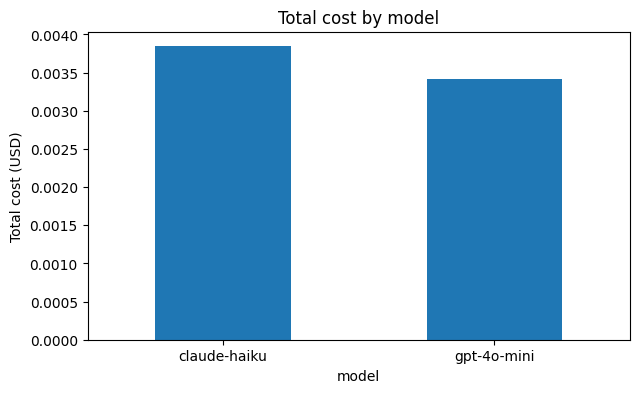

In [24]:
import matplotlib.pyplot as plt

# Total cost per model — a quick bar chart, sorted so the ranking is obvious
cost_by_model = df.groupby("model")["cost_usd"].sum().sort_values(ascending=False)

ax = cost_by_model.plot(kind="bar", title="Total cost by model", rot=0, figsize=(7, 4))
ax.set_ylabel("Total cost (USD)")
plt.show()


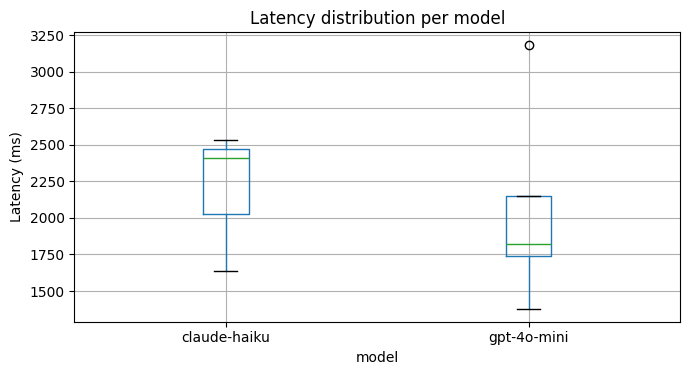

In [25]:
# Latency distribution per model — boxplot
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column="latency_ms", by="model", ax=ax)
ax.set_title("Latency distribution per model")
ax.set_ylabel("Latency (ms)")
plt.suptitle("")     # suppress the auto-title pandas adds
plt.tight_layout()
plt.show()


## 12. The pandas patterns you'll see everywhere

Burn these into memory — they form the daily-use vocabulary of every data scientist:

```python
# Loading
df = pd.read_csv("data.csv")

# Exploring
df.head()                       # see the first rows
df.shape                        # rows, cols
df.describe()                   # summary stats
df.info()                       # types and missing counts

# Selecting
df["col"]                       # one column → Series
df[["col1", "col2"]]            # several columns → DataFrame
df.loc[label, "col"]            # row by label, column by name
df.iloc[0, 0]                   # row by position, column by position

# Filtering
df[df["col"] > 100]
df[(df["col1"] > 100) & (df["col2"] == "x")]

# Adding columns
df["new"] = df["a"] * df["b"]
df["band"] = pd.cut(df["score"], bins=..., labels=...)

# Aggregating
df.groupby("category")["value"].mean()
df.groupby("category").agg(total=("value", "sum"))

# Quick visual
df["amount"].plot(kind="hist", bins=30)
```

Once these feel automatic, the rest of pandas is "more of the same".

## 🧪 Practice exercises

For the next exercises we'll use a slightly larger synthetic dataset: 50 API calls across models, segments, and quarters.

In [26]:
rng = np.random.default_rng(42)
n = 50

api_data = pd.DataFrame({
    "request_id": [f"req_{i:03d}" for i in range(1, n + 1)],
    "model":      rng.choice(["gpt-4o-mini", "claude-haiku", "gpt-4o"], n),
    "segment":    rng.choice(["SMB", "Mid-market", "Enterprise"], n),
    "quarter":    rng.choice(["Q1", "Q2", "Q3", "Q4"], n),
    "tokens":     rng.integers(120, 2000, n).astype(int),
    "latency_ms": rng.integers(800, 4500, n),
    "user_age":   rng.integers(20, 65, n),
})
api_data.head()


,request_id,model,segment,quarter,tokens,latency_ms,user_age
0,req_001,gpt-4o-mini,Enterprise,Q4,1728,2155,28
1,req_002,gpt-4o,SMB,Q1,649,4161,42
2,req_003,claude-haiku,Mid-market,Q4,1845,2631,28
3,req_004,claude-haiku,Mid-market,Q1,671,3388,34
4,req_005,claude-haiku,Mid-market,Q4,936,2492,49


### Exercise 1 — ⭐ Basic exploration

1. Print the **shape** and **dtypes** of `api_data`.
2. Print the **mean** and **median** of `tokens`.
3. Show how many requests there were per `model`.

In [27]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
print(f"shape  = {api_data.shape}")
print(f"\ndtypes:\n{api_data.dtypes}")

print(f"\nmean tokens   = {api_data['tokens'].mean():.1f}")
print(f"median tokens = {api_data['tokens'].median():.1f}")

print("\nRequests per model:")
print(api_data['model'].value_counts())
```
</details>

### Exercise 2 — ⭐⭐ Filtering

Find all requests where **`tokens >= 1500` AND `latency_ms >= 3000`** (the expensive, slow ones). How many are there, and what's their mean latency?

In [28]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
expensive_slow = api_data[(api_data["tokens"] >= 1500) & (api_data["latency_ms"] >= 3000)]

print(f"Matching rows : {len(expensive_slow)}")
print(f"Mean latency  : {expensive_slow['latency_ms'].mean():.0f} ms")
expensive_slow.head()
```

These are the calls worth profiling first — biggest cost *and* biggest user-experience hit.
</details>

### Exercise 3 — ⭐⭐ Group-by

For each `model`, compute:

1. Total `tokens`.
2. Number of requests.
3. The **segment** that consumed the most tokens for that model (think: groupby on two columns).

Tip: `df.groupby(["model", "segment"])["tokens"].sum()` returns a stacked Series — combine with `.idxmax()` or `.sort_values()`.

In [29]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
# 1 & 2: per-model summary
summary = api_data.groupby("model").agg(
    total_tokens =("tokens", "sum"),
    n_requests   =("tokens", "count"),
)
print(summary)

# 3: top segment per model
grouped = api_data.groupby(["model", "segment"])["tokens"].sum()
print("\nTop segment per model:")
print(grouped.groupby(level=0).idxmax())   # → (model, segment) tuples
```

The pattern `grouped.groupby(level=0).idxmax()` finds, *within each model group*, which segment had the highest total tokens — a one-line "argmax over a subgroup" trick worth remembering.
</details>

### Exercise 4 — ⭐⭐ Visual exploration

Create two plots:

1. A **bar chart** of total `tokens` per `model`.
2. A **histogram** of `latency_ms` with 10 bins.

Add titles and axis labels.

In [30]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1) Bar chart
api_data.groupby("model")["tokens"].sum().plot(
    kind="bar", ax=axes[0], color="#4C72B0", edgecolor="black"
)
axes[0].set_title("Total tokens per model")
axes[0].set_ylabel("Tokens")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.3)

# 2) Histogram
api_data["latency_ms"].plot(
    kind="hist", bins=10, ax=axes[1], color="#DD8452", edgecolor="black"
)
axes[1].set_title("Latency distribution")
axes[1].set_xlabel("Latency (ms)")

plt.tight_layout()
plt.show()
```
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

The cell below should print the **average latency per model** but it raises an error. Fix it.

In [31]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
# Buggy:
# print(api_data.groupby(model).mean(latency_ms))


<details>
<summary>💡 <b>Solution</b></summary>

Two issues:

1. `model` and `latency_ms` need to be **strings** (column names), not bare identifiers.
2. `.mean(latency_ms)` is not how you pick a column — `.mean()` takes no positional column name.

```python
print(api_data.groupby("model")["latency_ms"].mean().round(0))
```

Or, using `.agg`:

```python
print(api_data.groupby("model").agg(avg_latency=("latency_ms", "mean")).round(0))
```

Both work. The `.agg(...)` form is preferred once you want multiple aggregations at once.
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise C — ⭐⭐⭐ Pivot to a region × month revenue table

You have a long-format DataFrame:

```python
import pandas as pd
df = pd.DataFrame({
    "month":   ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "region":  ["EU",  "US",  "EU",  "US",  "EU",  "US"],
    "revenue":[110,    180,    130,    160,    140,    175],
})
```

Produce a **wide-format** table with months as rows and regions as columns, plus a `Total` column summing across regions.

In [32]:
# Your code here  👇
import pandas as pd
df = pd.DataFrame({
    "month":   ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "region":  ["EU",  "US",  "EU",  "US",  "EU",  "US"],
    "revenue":[110,    180,    130,    160,    140,    175],
})

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import pandas as pd
df = pd.DataFrame({
    "month":   ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "region":  ["EU",  "US",  "EU",  "US",  "EU",  "US"],
    "revenue":[110,    180,    130,    160,    140,    175],
})

wide = df.pivot(index="month", columns="region", values="revenue")
wide["Total"] = wide.sum(axis=1)
print(wide)
```

**Reasoning.** `pivot` is the textbook tool for long-to-wide reshaping. Three things worth noting. (1) The arguments form a sentence: "each `index` value becomes a row, each `columns` value becomes a column, populate with `values`." (2) The result is indexed by `month`, which may or may not preserve calendar order — set it with `wide.reindex(["Jan","Feb","Mar"])` if you need a specific order. (3) `wide.sum(axis=1)` sums along rows (each row's two region values) — `axis=0` would sum each column. Choosing the right axis is one of pandas's most common off-by-one mistakes, so always read it aloud: *"sum across the rows, leaving one number per row."*
</details>

### Stretch exercise D — ⭐⭐⭐ IQR-based outlier detection per group

Given the DataFrame below, flag rows where `value` is more than 1.5 × IQR outside its group's quartile range — i.e. apply the classic boxplot rule **separately per group**.

```python
df = pd.DataFrame({
    "group": ["A"]*8 + ["B"]*8,
    "value": [10, 12, 11, 13, 10, 14, 12, 90,
              50, 52, 49, 51, 53, 50, 1, 52],
})
```

Add an `is_outlier` boolean column. Expected: row 7 (value 90 in A) and row 14 (value 1 in B) are flagged.

In [33]:
# Your code here  👇
import pandas as pd
df = pd.DataFrame({
    "group": ["A"]*8 + ["B"]*8,
    "value": [10, 12, 11, 13, 10, 14, 12, 90,
              50, 52, 49, 51, 53, 50, 1, 52],
})

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import pandas as pd
df = pd.DataFrame({
    "group": ["A"]*8 + ["B"]*8,
    "value": [10, 12, 11, 13, 10, 14, 12, 90,
              50, 52, 49, 51, 53, 50, 1, 52],
})

def flag_outliers(s: pd.Series) -> pd.Series:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (s < lo) | (s > hi)

df["is_outlier"] = df.groupby("group")["value"].transform(flag_outliers)
print(df)
```

**Reasoning.** Two important pandas patterns at once. (1) The boxplot rule — `Q1 - 1.5·IQR` and `Q3 + 1.5·IQR` as outlier fences — is robust to skewed data because it uses quantiles, not means. It's the rule matplotlib's `.boxplot` whiskers use by default. (2) `groupby(...).transform(fn)` is the right tool whenever you want **per-group computation back at row level** (same number of rows in, same number out). Compare with `.apply` (can return any shape) and `.agg` (collapses each group to one row). Using `transform` lets us assign the result back as a column in one line.
</details>

## 🧠 Key takeaways

1. A **DataFrame** is a labelled table; a **Series** is one column.
2. Use `df.head() / .shape / .dtypes / .info() / .describe()` to inspect a new dataset.
3. Select columns with `df["col"]` or `df[[col1, col2]]`; rows with `.loc[label]` or `.iloc[position]`.
4. **Boolean masks** drive filtering: `df[mask]`. Combine masks with `&`, `|`, `~`, and wrap each condition in parentheses.
5. **`groupby` → aggregation** is the workhorse of analysis (`mean`, `sum`, `count`, custom funcs).
6. **Derived columns** turn raw data into KPIs — vectorised arithmetic, no loops.
7. `df.plot()` gets you to a chart in one line.
8. `pd.read_csv` / `df.to_csv` is the universal I/O — almost every project starts and ends there.

And the one idea under all of it: every task was just **pick rows, pick columns, or compute** — the three moves that took our API-call log from raw rows to *"this model and that segment are driving the cost."*

## ✅ Self-assessment

- [ ] Build a DataFrame from a dict-of-lists
- [ ] Inspect a new dataset with `head()`, `shape`, `dtypes`, `info()`, `describe()`
- [ ] Select columns and rows with `.loc` and `.iloc`
- [ ] Filter rows with a boolean mask combining multiple conditions
- [ ] Add a derived column from a formula
- [ ] Use `groupby(...).agg(...)` to compute multiple aggregates per group
- [ ] Read a CSV and write one back

## 🚀 Next step

Continue with **Notebook 7 (fast track) — Visualization & Statistics**, where you'll turn these DataFrames into charts that make the pattern obvious and statistics that tell you whether the pattern is real.